In [1]:
import os
import sys
sys.path.append("..")  # Adds higher directory to python modules path.

import numpy as np
from src import sCMOSFunctions
import matplotlib.pyplot as plt
from copy import copy

sCMOS = sCMOSFunctions.sCMOS_Functions()

from src import PSFFunctions

PSF = PSFFunctions.PSF_Functions()

from src import MaskFunctions

MF = MaskFunctions.Mask_Functions()

from src import CalibrationFunctions

C_F = CalibrationFunctions.Calibration_Functions()

import xarray as xr

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()


In [ ]:
import pandas as pd

In [ ]:
folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Sycamore/20240520_SingleAB/data_analysis'

In [ ]:
files = os.listdir(folder)
files = np.sort([x for x in files if '.csv' in x])

In [ ]:
data = None
for file in files:
    if data is None:
        data = pd.read_csv(os.path.join(folder, file))
    else:
        data = pd.concat([data, pd.read_csv(os.path.join(folder, file))])
data = data.reset_index()

In [ ]:
data['SBR'] = data['intensity [photon]'].values/data['offset [photon]'].values

In [ ]:
data = data[data['SBR'] > 1]
data = data[data['SBR'] < 1000]

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.histogram_plot(axs=axs,
                             data=data['intensity [photon]'].values, 
                             bins=np.histogram_bin_edges(data['intensity [photon]'].values, bins='fd'),
                            xaxislabel='punctum intensity (photons)', label='N='+str(len(data['intensity [photon]'].values)))
axs.set_xlim([0, 3000])
axs.legend(loc='best')
savefolder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250227/fig/ASAP_SingleAB/'
plt.savefig(os.path.join(savefolder, 'Example_Plot_SingleAB.svg'), dpi=600, format='svg')

In [ ]:
def lognormal(x, x0, sigma, c):
    prefactor = np.divide(1., (x*sigma*np.sqrt(2*np.pi)))
    exponential_term = -np.divide(np.square(np.log(x) - np.log(c*x0)), 2*np.square(sigma))
    rho = prefactor*np.exp(exponential_term)
    return rho

In [ ]:
fig, axs = plotter.one_column_plot()

N = len(data['intensity [photon]'].values)
axs = plotter.histogram_plot(axs=axs,
                             data=data['intensity [photon]'].values, 
                             bins=np.histogram_bin_edges(data['intensity [photon]'].values, bins='fd'),
                            xaxislabel='punctum intensity (photons)', label='N='+str(N), density=False)
axs.set_xlim([0, 3000])
axs.legend(loc='best')


c = 1
x0 = 270
sigma = 0.7

y=lognormal(x, x0, sigma, c)
y=y/np.sum(y)
axs = plotter.line_plot(axs=axs,
                        x=x,
                        y=y*(3.9*N), color='red', lw=1, xaxislabel='punctum intensity (photons',
                       yaxislabel='frequency')
axs.set_ylim([0, 3500])

In [2]:
directory = '/media/jbeckwith/Ezra Seagat/JSB/20250220_XimeaCharacterisation/data/2500ms/2500ms_1/'
intensity_string = '2500ms'
mean_2500ms = C_F.calculate_offset(directory, intensity_string)

In [3]:
directory = '/media/jbeckwith/Ezra Seagat/JSB/20250220_XimeaCharacterisation/data/50ms/50ms_1/'
intensity_string = '50ms'
mean_50ms = C_F.calculate_offset(directory, intensity_string)

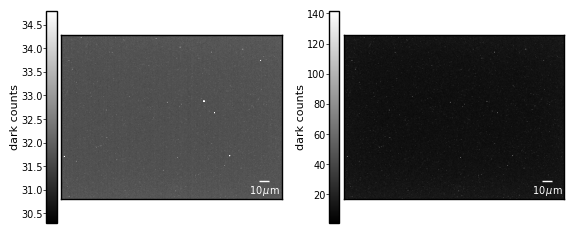

In [10]:
fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1,1])

axs[0] = plotter.image_plot(axs=axs[0], data=mean_50ms, cbarlabel='dark counts')

axs[1] = plotter.image_plot(axs=axs[1], data=mean_2500ms, cbarlabel='dark counts')


folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250227/fig/multicolour_camera/Ximea/'

plt.savefig(os.path.join(folder, 'Dark_50vs2500.svg'), dpi=600, format='svg')

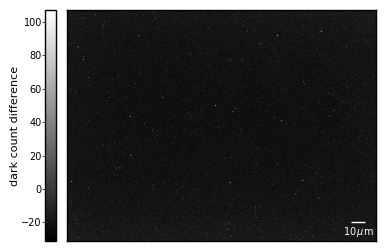

In [13]:
fig, axs = plotter.two_column_plot()

axs = plotter.image_plot(axs=axs, data=mean_2500ms-mean_50ms, cbarlabel='dark count difference')


folder = '/home/jbeckwith/Documents/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Subgroup/20250227/fig/multicolour_camera/Ximea/'

plt.savefig(os.path.join(folder, 'Dark_difference.svg'), dpi=600, format='svg')

In [ ]:
from src import IOFunctions

IO = IOFunctions.IO_Functions()

from Camera_QE import getpixelefficiency

gpe = getpixelefficiency.GPE()
R, G, B, wavelength = gpe.getpixelefficiency("Camera_QE/CS505CU_QE.csv")

In [ ]:
data_folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [ ]:
image_size = 100

camera_calibration = {}
camera_calibration["gain"] = gain[:image_size, :image_size]
camera_calibration["offset"] = offset[:image_size, :image_size]
camera_calibration["variance"] = variance[:image_size, :image_size]
camera_calibration["readnoise"] = readnoise[:image_size, :image_size]
camera_calibration["rqe"] = rqe[:image_size, :image_size]

In [ ]:
image = np.random.normal(size=(image_size, image_size))

In [ ]:
import numpy as np  # import numerical python
import matplotlib.pyplot as plt  # import plotting functions
import seaborn as sns  # import nicer plotting functions
import polars as pl  # import polars to import data
import tifffile as tiff
from tifffile import imwrite, imread
from copy import deepcopy
import os
import time

from src import IOFunctions

IO = IOFunctions.IO_Functions()

from src import Multicolour_Simulation_Functions

MSF = Multicolour_Simulation_Functions.MultiC_Sim_Funcs()

from src import PlottingFunctions

plotter = PlottingFunctions.Plotter()

import colour

from colour_demosaicing import (
    ROOT_RESOURCES_EXAMPLES,
    demosaicing_CFA_Bayer_bilinear,
    demosaicing_CFA_Bayer_Malvar2004,
    demosaicing_CFA_Bayer_Menon2007,
    mosaicing_CFA_Bayer,
)

In [ ]:
MSF.mosaic_unit

In [ ]:
data_folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Salix/CS505CU_Calibration"
gain = IO.read_tiff(os.path.join(data_folder, "gain.tif"))
offset = IO.read_tiff(os.path.join(data_folder, "offset.tif"))
variance = IO.read_tiff(os.path.join(data_folder, "variance.tif"))
readnoise = IO.read_tiff(os.path.join(data_folder, "readnoise.tif"))
rqe = IO.read_tiff(os.path.join(data_folder, "rqe.tif"))

In [ ]:
from Camera_QE import getpixelefficiency

gpe = getpixelefficiency.GPE()
R, G, B, wavelength = gpe.getpixelefficiency("Camera_QE/CS505CU_QE.csv")
wavelength = wavelength
absolute_QYs = np.vstack([B, G, R])
camera_calibration = {}
image_size = 20
camera_calibration["gain"] = gain[:image_size, :image_size]
camera_calibration["offset"] = offset[:image_size, :image_size]
camera_calibration["variance"] = variance[:image_size, :image_size]
camera_calibration["readnoise"] = readnoise[:image_size, :image_size]
camera_calibration["rqe"] = rqe[:image_size, :image_size]

background_photons = 0
pixel_size = 69
NA = 1.49
n_photons = {}
n_photons["ATTO550"] = 4000

dyes = np.zeros([1, len(wavelength)])
folder = "Spectra/Em/Dyes/"
emission_spectra = np.sort(os.listdir(folder))

separator = "\t"
skip_rows = 1

data = pl.read_csv(
    os.path.join(folder, emission_spectra[28]), separator=separator, skip_rows=skip_rows
)
d_wl = data[:, 0].to_numpy()
d_em = data[:, 1].to_numpy()
ATTO550 = np.interp(x=wavelength, xp=d_wl, fp=d_em)
ATTO550 = ATTO550 / np.sum(ATTO550)
dyes[0, :] = ATTO550


x0y0 = {}
max = pixel_size * image_size

x0y0["ATTO550"] = np.array([[max / 2], [max / 2]])

In [ ]:
ground_truth, bayer_image = MSF.gen_camera_images(
    camera_calibration,
    wavelength,
    absolute_QYs,
    dyes,
    n_photons,
    x0y0,
    background_photons=background_photons,
    NA=NA,
    pixel_size=pixel_size,
)

In [ ]:
photoelectron_data = np.divide(
    np.divide(
        np.subtract(bayer_image, camera_calibration["offset"]),
        camera_calibration["gain"],
    ),
    camera_calibration["rqe"],
)
erd = copy(photoelectron_data)
# erd = sCMOS.var_weighted_uniform_filter(
#    photoelectron_data, camera_calibration["variance"], 4
# )
erd[erd < 0] = 0
erd = erd + 1
error_map = np.add(erd, camera_calibration["readnoise"])
weights_map = np.power(error_map, -2)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=np.sqrt(error_map),
    pixelsize=69,
    scalebarsize=300,
    vmin=0,
    vmax=5,
    scalebarlabel="300 nm",
    cbarlabel="error / photoelectron",
)

savefolder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera"
plt.tight_layout()
plt.savefig(
    os.path.join(savefolder, "Error_map_Poission_nosmoothing.svg"),
    format="svg",
    dpi=600,
)
plt.show()

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=camera_calibration["readnoise"],
    pixelsize=69,
    scalebarsize=300,
    vmin=0,
    vmax=5,
    scalebarlabel="300 nm",
    cbarlabel="read noise / photoelectron",
)

savefolder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera"
plt.tight_layout()
plt.savefig(os.path.join(savefolder, "Error_map_readnoise.svg"), format="svg", dpi=600)
plt.show()

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=photoelectron_data,
    pixelsize=69,
    scalebarsize=300,
    vmin=0,
    scalebarlabel="300 nm",
    cbarlabel="signal / photoelectron",
)

savefolder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera"
plt.tight_layout()
plt.savefig(os.path.join(savefolder, "Photoelectron_map.svg"), format="svg", dpi=600)
plt.show()

In [ ]:
def gaussian_model(xc, yc, A, sigma, b):
    """
    lambda function to simulate a gaussian psf.

    Args:
        xc (float): centroid position in x.
        yc (float): centroid position in y.
        A (float): amplitude.
        sigma (float): width
        b (float): background

    Returns:
        lambda function (numpy.ndarray): simulated 2D gaussian.
    """
    return lambda x, y: np.multiply(
        A,
        np.exp(
            -np.divide(
                (
                    np.square(np.subtract(xc, x) / sigma)
                    + np.square(np.subtract(yc, y) / sigma)
                ),
                2,
            )
        )
        + np.sqrt(np.square(b)),
    )

In [ ]:
data = np.zeros([100, 100])

In [ ]:
dye_names = x0y0.keys()

gain = camera_calibration["gain"]
offset = camera_calibration["offset"]
variance = camera_calibration["variance"]
relative_QE = camera_calibration["rqe"]

average_emission_wavelengths = np.trapz(
    y=wavelength * (dyes.T / np.trapz(x=wavelength, y=dyes)).T, x=wavelength
)
sigma_PSFs = PSF.diffraction_limit(average_emission_wavelengths, NA)
pixel_colours = np.sort(np.unique(MSF.mosaic_unit))

dye_pixel_efficiency = np.dot(dyes, absolute_QYs.T)
overall_QY = np.sum(dye_pixel_efficiency, axis=1)

h = gain.shape[0]
w = gain.shape[1]

x = np.linspace(0, (pixel_size * h) - pixel_size, h)
y = np.linspace(0, (pixel_size * w) - pixel_size, w)

masks = MF.get_masks(MSF.mosaic_unit, h, w)

dims = ["im_width", "im_height", "n_colours"]

coords = [np.arange(w), np.arange(h), np.hstack([pixel_colours, "T"])]

bayer_image = np.zeros([w, h])

ground_truth = xr.DataArray(
    data=np.zeros([w, h, len(pixel_colours) + 1]), dims=dims, coords=coords
)

In [ ]:
dye = "ATTO550"
j = 0
i = 1
n_photons_hitting_detector = np.zeros(
    [gain.shape[0], gain.shape[1], len(dye_names)], dtype=int
)
n_photoelectrons = np.zeros_like(n_photons_hitting_detector)

In [ ]:
x0 = x0y0[dye][0, :]
y0 = x0y0[dye][1, :]
sigma_psf = sigma_PSFs[j]

abs_QE = dye_pixel_efficiency[j, i]

photon_spatial_pdf = PSF.gen_spatial_PSF(
    x, y, sigma_psf, x0, y0, n_photons[dye], relative_QE
)

# TODO: add background into generation functions
n_photons_hitting_detector[:, :, j] = PSF.gen_photons_hitting_detector(
    photon_spatial_pdf, background_photons
)

n_photoelectrons[:, :, j] = PSF.gen_photoelectrons(
    n_photons_hitting_detector[:, :, j], abs_QE
)

image_matrix = PSF.photoelectrons_to_image(
    np.sum(n_photoelectrons, axis=-1), gain, offset, variance
)

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=photon_spatial_pdf,
    scalebarsize=300,
    pixelsize=69,
    scalebarlabel="300 nm",
)

savefolder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera"
plt.tight_layout()
plt.savefig(
    os.path.join(savefolder, "Input_PhotonDistribution.svg"), format="svg", dpi=600
)
plt.show()

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=n_photons_hitting_detector[:, :, j],
    scalebarsize=300,
    pixelsize=69,
    scalebarlabel="300 nm",
    cbarlabel="photons hitting detector",
)

savefolder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera"
plt.tight_layout()
plt.savefig(
    os.path.join(savefolder, "Input_Nphotons_hittingdetector.svg"),
    format="svg",
    dpi=600,
)
plt.show()

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=n_photoelectrons[:, :, j],
    scalebarsize=300,
    pixelsize=69,
    scalebarlabel="300 nm",
    cbarlabel="photoelectrons",
)

savefolder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera"
plt.tight_layout()
plt.savefig(
    os.path.join(savefolder, "Input_nphotoelectrons.svg"), format="svg", dpi=600
)
plt.show()

In [ ]:
fig, axs = plotter.one_column_plot()

axs = plotter.image_plot(
    axs=axs,
    data=image_matrix,
    scalebarsize=300,
    pixelsize=69,
    scalebarlabel="300 nm",
    cbarlabel="image intensity",
)

savefolder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera"
plt.tight_layout()
plt.savefig(
    os.path.join(savefolder, "Input_finalsimulatedimage.svg"), format="svg", dpi=600
)
plt.show()

In [ ]:
import polars as pl

In [ ]:
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241023/data"
fittesting_ATTO390 = pl.read_csv(
    os.path.join(folder, "ATTO390_fittesting_RMSE_mean_Gaussianestimation.csv")
)
fittesting_ATTO390_VU = pl.read_csv(
    os.path.join(folder, "ATTO390_fittesting_RMSE_mean_varuniform.csv")
)
fittesting_ATTO390_VU_RN = pl.read_csv(
    os.path.join(folder, "ATTO390_fittesting_RMSE_mean_VUxyestimation.csv")
)

In [ ]:
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241023/data"
fittesting_ATTO488 = pl.read_csv(
    os.path.join(folder, "ATTO488_fittesting_RMSE_mean_Gaussianestimation.csv")
)
fittesting_ATTO488_VU = pl.read_csv(
    os.path.join(folder, "ATTO488_fittesting_RMSE_mean_varuniform.csv")
)
fittesting_ATTO488_VU_RN = pl.read_csv(
    os.path.join(folder, "ATTO488_fittesting_RMSE_mean_VUxyestimation.csv")
)

In [ ]:
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241023/data"
fittesting_ATTO550 = pl.read_csv(
    os.path.join(folder, "ATTO550_fittesting_RMSE_mean_Gaussianestimation.csv")
)
fittesting_ATTO550_VU = pl.read_csv(
    os.path.join(folder, "ATTO550_fittesting_RMSE_mean_varuniform.csv")
)
fittesting_ATTO550_VU_RN = pl.read_csv(
    os.path.join(folder, "ATTO550_fittesting_RMSE_mean_VUxyestimation.csv")
)

In [ ]:
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241023/data"
fittesting_ATTO647N = pl.read_csv(
    os.path.join(folder, "ATTO647N_fittesting_RMSE_mean_Gaussianestimation.csv")
)
fittesting_ATTO647N_VU = pl.read_csv(
    os.path.join(folder, "ATTO647N_fittesting_RMSE_mean_varuniform.csv")
)
fittesting_ATTO647N_VU_RN = pl.read_csv(
    os.path.join(folder, "ATTO647N_fittesting_RMSE_mean_VUxyestimation.csv")
)

In [ ]:
folder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Data/Simulation/20241023/data"
fittesting_ATTO740 = pl.read_csv(
    os.path.join(folder, "ATTO740_fittesting_RMSE_mean_Gaussianestimation.csv")
)
fittesting_ATTO740_VU = pl.read_csv(
    os.path.join(folder, "ATTO740_fittesting_RMSE_mean_varuniform.csv")
)
fittesting_ATTO740_VU_RN = pl.read_csv(
    os.path.join(folder, "ATTO740_fittesting_RMSE_mean_VUxyestimation.csv")
)

In [ ]:
fittest = (fittesting_ATTO390 + fittesting_ATTO488 + fittesting_ATTO550) / 3
fittest_VU = (fittesting_ATTO390_VU + fittesting_ATTO488_VU + fittesting_ATTO550_VU) / 3
fittest_VU_RN = (
    fittesting_ATTO390_VU_RN + fittesting_ATTO488_VU_RN + fittesting_ATTO550_VU_RN
) / 3

In [ ]:
cs = ["#cb6a49", "#7aa457", "#a46cb7"]

fig, axs = plotter.two_column_plot(ncolumns=2, widthratio=[1, 1])

axs[0] = plotter.scatter_plot(
    axs=axs[0],
    x=fittest["n_photons"].to_numpy(),
    y=0.5 * (fittest["xc"].to_numpy() + fittest["yc"].to_numpy()),
    xaxislabel="number of photons",
    yaxislabel="distance RMSE / nm",
    label="only read noise considered",
    edgecolor=cs[0],
    marker="o",
)

axs[0] = plotter.scatter_plot(
    axs=axs[0],
    x=fittest_VU["n_photons"].to_numpy(),
    y=0.5 * (fittest_VU["xc"].to_numpy() + fittest_VU["yc"].to_numpy()),
    xaxislabel="number of photons",
    yaxislabel="distance RMSE / nm",
    label="uniform smoothed photon counts considered",
    edgecolor=cs[1],
    marker="v",
)


axs[0] = plotter.scatter_plot(
    axs=axs[0],
    x=fittest_VU_RN["n_photons"].to_numpy(),
    y=0.5 * (fittest_VU_RN["xc"].to_numpy() + fittest_VU_RN["yc"].to_numpy()),
    xaxislabel="number of photons",
    yaxislabel="distance RMSE / nm",
    label="uniform smoothed initial estimate",
    edgecolor=cs[2],
    marker="s",
)

axs[0].set_xscale("log")
axs[0].set_ylim([1, 100])
axs[0].set_yscale("log")
axs[0].legend(loc="best", fontsize=6)

axs[1] = plotter.scatter_plot(
    axs=axs[1],
    x=fittest["n_photons"].to_numpy(),
    y=(1.0 / 3)
    * (fittest["R"].to_numpy() + fittest["G"].to_numpy() + fittest["B"].to_numpy()),
    xaxislabel="number of photons",
    yaxislabel="colour RMSE / normalised",
    edgecolor=cs[0],
)

axs[1] = plotter.scatter_plot(
    axs=axs[1],
    x=fittest_VU["n_photons"].to_numpy(),
    y=(1.0 / 3)
    * (
        fittest_VU["R"].to_numpy()
        + fittest_VU["G"].to_numpy()
        + fittest_VU["B"].to_numpy()
    ),
    xaxislabel="number of photons",
    yaxislabel="colour RMSE / normalised",
    edgecolor=cs[1],
    marker="v",
)


axs[1] = plotter.scatter_plot(
    axs=axs[1],
    x=fittesting_ATTO390_VU_RN["n_photons"].to_numpy(),
    y=(1.0 / 3)
    * (
        fittest_VU_RN["R"].to_numpy()
        + fittest_VU_RN["G"].to_numpy()
        + fittest_VU_RN["B"].to_numpy()
    ),
    xaxislabel="number of photons",
    yaxislabel="colour RMSE / normalised",
    edgecolor=cs[2],
    marker="s",
)

axs[1].set_xscale("log")
axs[1].set_ylim([5e-3, 0.15])
plt.yscale("log")
plt.tight_layout()
savefolder = "/home/jbeckwith/Documents/Dropbox/Cambridge University Dropbox/Joseph Beckwith/Chemistry/Lee/Talks+Posters/Group Meeting/20241104/fig/multicolour_camera"

plt.savefig(
    os.path.join(savefolder, "Overall_Algorithm_Reliability.svg"), format="svg", dpi=600
)
plt.show()